# Pipeline stage 3: characterization of phage-encoded acetyltransferase Map

### Stage 3.4: impact of Map-targeted lysine acetylation on MetK (visualization of MetK enzymatic assay)

In our research, we have characterized LUZ19 gp13/Map, and identified MetK as one of its targets. To assess the potential functional impact of lysine acetylation on MetK residues 285 and 386, we carried out an enzymatic assay (as described by Ames & Dubin) of MetK activity, comparing wild type and acetylation mimic mutants. In this notebook, we will parse and visualize these results, to help interpreting them.

**Goals:**
* Parse Ames & Dubin test data.
* Visualize Ames & Dubin test data.

**Requires:**
* OD820 measurments from the Ames & Dubin experiment in file AmesDubin.tsv, stored in data/: tab-separated file containing the endpoint OD820 measurements of the Ames & Dubin experiment to measure MetK activity. 

**Generates:**
* AmesDubin.svg : scatterplot visualizing the endpoint OD820 measurements of the Ames & Dubin experiment to measure MetK activity, for different MetK variants. 

#### General settings, imports, variables and environments

Conda environment: viral_act_metk

Created with `conda create -n viral_act_metk python=3.10`. Then installed  `jupyter notebook`, `pandas` through conda (command `conda install`), and `seaborn`, `scipy` through pip (command below).

In [1]:
!pip install seaborn

In [2]:
!pip install scipy

In [3]:
!conda list --explicit

# This file may be used to create an environment using:
# $ conda create --name <env> --file <this file>
# platform: win-64
# created-by: conda 24.11.3
@EXPLICIT
https://conda.anaconda.org/conda-forge/noarch/ca-certificates-2026.5.20-h4c7d964_0.conda
https://conda.anaconda.org/conda-forge/win-64/onemkl-license-2026.0.0-h57928b3_908.conda
https://conda.anaconda.org/conda-forge/noarch/python_abi-3.10-8_cp310.conda
https://conda.anaconda.org/conda-forge/noarch/tzdata-2025c-hc9c84f9_1.conda
https://conda.anaconda.org/conda-forge/win-64/ucrt-10.0.26100.0-h57928b3_0.conda
https://conda.anaconda.org/conda-forge/win-64/winpty-0.4.3-4.tar.bz2
https://conda.anaconda.org/conda-forge/win-64/libwinpthread-12.0.0.r4.gg4f2fc60ca-h57928b3_10.conda
https://conda.anaconda.org/conda-forge/win-64/vcomp14-14.51.36231-h1b9f54f_37.conda
https://conda.anaconda.org/conda-forge/win-64/vc14_runtime-14.51.36231-h1b9f54f_37.conda
https://conda.anaconda.org/conda-forge/win-64/vc-14.5-h1b7c187_37.conda
https://conda

In [4]:
# imports 
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [5]:
# clear reference to different directories
pipeline_map_dir = os.getcwd()
master_dir = os.path.abspath(os.path.join(pipeline_map_dir, os.pardir, os.pardir))

In [ ]:
# creating a directory for all the data we will generate
os.mkdir(os.path.join(pipeline_map_dir, "d_MetK"))

#### Goal 1 : parse Ames & Dubin test data

Let's first read in the table containing the endpoint OD820 measurements.

In [6]:
# reading in the data as is
od = pd.read_csv(os.path.join(pipeline_map_dir, "d_MetK", "data", "AmesDubin.tsv"), sep = "\t", decimal = ",")
od

,Unnamed: 0,blank,wt - NC,K285Q - NC,K285R - NC,K386Q - NC,K386R - NC,wt,K285Q,K285R,K386Q,K386R
0,replica 1,0.214,0.648,0.640,0.548,0.534,0.419,1.684,1.803,1.690,1.428,1.555
1,replica 2,0.238,0.230,0.283,0.266,0.263,0.077,1.014,1.017,1.071,1.052,0.593
2,replica 3,0.225,0.220,0.268,0.252,0.267,0.250,1.169,1.158,1.133,1.087,0.879


Let's correct this raw data, by first substracting the blank values. 

In [10]:
# let's first correct the values by substracting the blank values
od_corrected = od.iloc[:, 1:].copy()
od_corrected = od_corrected.sub(od_corrected["blank"], axis = 0)

Let's now calculate the actual enzymatic activity per variant, by substracting the background measurement levels (in the absence of MetK substrate methionine).

In [11]:
# let's also create a dataframe where we have the delta values (substracting OD from those without any substrate)
od_delta = pd.DataFrame({
    'wt': od_corrected['wt'] - od_corrected['wt - NC'],
    'K285Q': od_corrected['K285Q'] - od_corrected['K285Q - NC'],
    'K285R': od_corrected['K285R'] - od_corrected['K285R - NC'],
    'K386Q': od_corrected['K386Q'] - od_corrected['K386Q - NC'],
    'K386R': od_corrected['K386R'] - od_corrected['K386R - NC'],
})
od_delta

,wt,K285Q,K285R,K386Q,K386R
0,1.036,1.163,1.142,0.894,1.136
1,0.784,0.734,0.805,0.789,0.516
2,0.949,0.890,0.881,0.820,0.629


Let's finally check whether any of these variants behave differently, by performing a Kruskal-Wallis test. This non-parametric test was chosen due the very limited sample size (n = 3 per variant), which violates the assumptions of an ANOVA.  

In [12]:
stats.kruskal(od_delta['wt'], od_delta['K285Q'], od_delta['K285R'], od_delta['K386Q'], od_delta['K386R'])

KruskalResult(statistic=np.float64(1.7000000000000028), pvalue=np.float64(0.7907176241051438))

As we can see, the variants are not statistically different (p = 0.79). Given the limited sample size and the corresponding non-parametric test, this is however not very surprising. 

#### Goal 2 : visualize Ames & Dubin test data

We have observed no statistical difference amongst the different variants, however, that is not very surprising given the small sample size. Let's also visualize the data to get a better understanding of it.

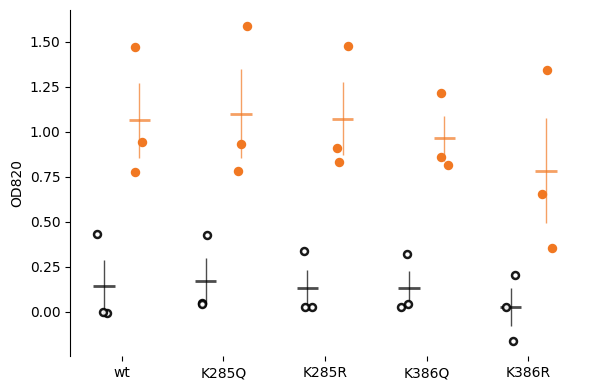

In [18]:
# define the different conditions
    # the different MetK variants
variants = od_delta.columns.tolist()
    # the presence or absence of substrate for each MetK variant
no_substrate_col = [f"{var} - NC" for var in variants]
substrate_col = variants

# extract the data for plotting
plot_data = []
for var in variants:
    for i in range(len(od_corrected)):
        plot_data.append({"variant": var, "condition": "- substrate", "value": od_corrected.loc[i, f"{var} - NC"]})
        plot_data.append({"variant": var, "condition": "+ substrate", "value": od_corrected.loc[i, f"{var}"]})
plot_df = pd.DataFrame(plot_data)

# actually plot
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(variants))

# compute means
means_no_sub = [plot_df[(plot_df.variant == var) & (plot_df.condition == "- substrate")]["value"].mean() for var in variants]
means_sub = [plot_df[(plot_df.variant == var) & (plot_df.condition == "+ substrate")]["value"].mean() for var in variants]
# compute standard error of the mean
sem_no_sub = [plot_df[(plot_df.variant == var) & (plot_df.condition == "- substrate")]["value"].sem() for var in variants]
sem_sub = [plot_df[(plot_df.variant == var) & (plot_df.condition == "+ substrate")]["value"].sem() for var in variants]
# loop over the different MetK variants
for i, var in enumerate(variants):
    # extract the OD820 mean values for the current variant and condition
    mean_no_sub = means_no_sub[i]
    mean_sub = means_sub[i]
    # draw horizontal lines for the mean OD820 values
    ax.hlines(mean_no_sub, x[i] - line_width/2 - width/2, x[i] + line_width/2 - width/2, colors = "black", alpha = 0.7, linewidth = 2)
    ax.hlines(mean_sub, x[i] - line_width/2 + width/2, x[i] + line_width/2 + width/2, colors = "#f17822", alpha = 0.7, linewidth = 2)
    # draw error bars for the standard error of the mean
    width = 0.35
    line_width = width * 0.6 
    ax.errorbar(x[i] - width/2, means_no_sub[i], yerr=sem_no_sub[i], fmt = "none", ecolor = "black", alpha = 0.7, linewidth = 1)
    ax.errorbar(x[i] + width/2, means_sub[i], yerr=sem_sub[i], fmt = "none", ecolor = "#f17822", alpha = 0.7, linewidth = 1)
    # extract the OD820 values for the current variant and condition
    vals_no_sub = plot_df[(plot_df.variant == var) & (plot_df.condition == "- substrate")]["value"]
    vals_sub = plot_df[(plot_df.variant == var) & (plot_df.condition == "+ substrate")]["value"]
    # add these as scatter points with some jitter for better visibility
    jitter = 0.08
    ax.scatter(np.full(len(vals_no_sub), x[i] - width/2) + np.random.uniform(-jitter, jitter, size = len(vals_no_sub)),
               vals_no_sub, color = "white", edgecolors = "black", s = 25, zorder = 3, linewidth = 1.8, alpha = 0.9)
    ax.scatter(np.full(len(vals_sub), x[i] + width/2) + np.random.uniform(-jitter, jitter, size = len(vals_sub)),
               vals_sub, color = "#f17822", edgecolors = "#f17822", s = 25, zorder = 3, linewidth = 1.8)

# final plot settings
ax.set_xticks(x)
ax.set_xticklabels(variants)
ax.set_ylabel("OD820")
sns.despine(bottom = True)
plt.tight_layout()

plt.show()

# to save the plot without labels, uncomment this
ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(labelbottom = False, labelleft = False)
fig.savefig(os.path.join(pipeline_map_dir, "d_MetK", f"AmesDubin.svg"), format = "svg", transparent = True)

